In [14]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.cross_decomposition import CCA
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

import anndata as ad
import h5py

In [15]:
data_dir = "/Users/mridulav/Downloads/datapreprocessed_output"
base = "mouse_V11T16_085_C1"

X = np.load(os.path.join(data_dir, f"{base}_X_rna.npy"))
Y = np.load(os.path.join(data_dir, f"{base}_X_msi.npy"))

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(X)
Y = scaler_y.fit_transform(Y)

print(X.shape, Y.shape)

(2841, 2000) (2841, 1153)


In [16]:
latent_dim = 16

class Encoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


class DeepCCA(nn.Module):
    def __init__(self, G, M):
        super().__init__()
        self.gene_encoder = Encoder(G)
        self.msi_encoder = Encoder(M)

    def forward(self, x, y):
        return self.gene_encoder(x), self.msi_encoder(y)

In [5]:
def cca_loss(H1, H2, outdim_size=8):

    r = 1e-4
    eps = 1e-9

    m = H1.size(0)

    H1 = H1 - H1.mean(dim=0)
    H2 = H2 - H2.mean(dim=0)

    S11 = (H1.T @ H1) / (m - 1) + r * torch.eye(H1.size(1), device=H1.device)
    S22 = (H2.T @ H2) / (m - 1) + r * torch.eye(H2.size(1), device=H2.device)
    S12 = (H1.T @ H2) / (m - 1)

    E1, V1 = torch.linalg.eigh(S11)
    E2, V2 = torch.linalg.eigh(S22)

    S11_inv_sqrt = V1 @ torch.diag((E1 + eps).pow(-0.5)) @ V1.T
    S22_inv_sqrt = V2 @ torch.diag((E2 + eps).pow(-0.5)) @ V2.T

    T = S11_inv_sqrt @ S12 @ S22_inv_sqrt

    corr = torch.linalg.svdvals(T)[:outdim_size].sum()

    return -corr

In [6]:
device = torch.device("cpu")

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, Y_tensor)

n_val = int(0.1 * len(dataset))
n_train = len(dataset) - n_val

train_set, val_set = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False)

model = DeepCCA(X.shape[1], Y.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

best_val = float("inf")

In [7]:
for epoch in range(200):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        h1, h2 = model(xb, yb)

        loss = cca_loss(h1, h2)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            h1, h2 = model(xb, yb)
            val_loss += cca_loss(h1, h2).item()

    val_loss /= len(val_loader)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "/Users/mridulav/best_model.pt")

    print(epoch, train_loss, val_loss)

0 -2.261501359939575 -2.8223984241485596
1 -3.916240692138672 -3.160123586654663
2 -5.182675838470459 -3.332554817199707
3 -6.077307415008545 -3.3495755195617676
4 -6.680326080322265 -3.4319891929626465
5 -7.119525527954101 -3.469865560531616
6 -7.427931880950927 -3.4575393199920654
7 -7.623855209350586 -3.471536159515381
8 -7.744469738006591 -3.473573684692383
9 -7.8317972183227536 -3.4736368656158447
10 -7.886197948455811 -3.4820761680603027
11 -7.921866512298584 -3.4832935333251953
12 -7.944634342193604 -3.490013599395752
13 -7.95928955078125 -3.4860000610351562
14 -7.968451690673828 -3.4884026050567627
15 -7.975723457336426 -3.504121780395508
16 -7.977050399780273 -3.5013515949249268
17 -7.9825758934021 -3.503190279006958
18 -7.983055973052979 -3.495738983154297
19 -7.9843141555786135 -3.4983227252960205
20 -7.985450172424317 -3.491337299346924
21 -7.987760925292969 -3.491680145263672
22 -7.988482666015625 -3.5026750564575195
23 -7.988214683532715 -3.496922492980957
24 -7.990137100

In [17]:
model.load_state_dict(torch.load("/Users/mridulav/best_model.pt"))
model.eval()

H1_all, H2_all = [], []

with torch.no_grad():
    for xb, yb in DataLoader(TensorDataset(X_tensor, Y_tensor), batch_size=512):
        h1, h2 = model(xb.to(device), yb.to(device))
        H1_all.append(h1.cpu())
        H2_all.append(h2.cpu())

H1_all = torch.cat(H1_all).numpy()
H2_all = torch.cat(H2_all).numpy()

H1_train = H1_all[train_set.indices]
H2_train = H2_all[train_set.indices]
H1_val   = H1_all[val_set.indices]
H2_val   = H2_all[val_set.indices]

In [18]:
cca = CCA(n_components=8, max_iter=5000)
cca.fit(H1_train, H2_train)

U_val, V_val = cca.transform(H1_val, H2_val)

correlations = [np.corrcoef(U_val[:, i], V_val[:, i])[0, 1] for i in range(8)]
print("Validation canonical correlations:", np.round(correlations, 4))
print("Mean:", np.mean(correlations))

Validation canonical correlations: [0.7826 0.297  0.3103 0.4127 0.203  0.0364 0.2026 0.2177]
Mean: 0.3077732971558609


In [19]:
dist = cosine_distances(U_val, V_val)
ranks = [np.where(np.argsort(dist[i]) == i)[0][0] for i in range(len(U_val))]
ranks = np.array(ranks)
print("Top-1:", np.mean(ranks == 0))
print("Top-5:", np.mean(ranks < 5))
print("Top-10:", np.mean(ranks < 10))

U_all, V_all = cca.transform(H1_all, H2_all)

Top-1: 0.014084507042253521
Top-5: 0.0880281690140845
Top-10: 0.1795774647887324


In [20]:
with h5py.File("/Users/mridulav/Downloads/datapreprocessed_output/mouse_V11T16_085_C1_preprocessed.h5ad", "r+") as f:
    if "base" in f["uns/log1p"]:
        del f["uns/log1p/base"]

adata = ad.read_h5ad("/Users/mridulav/Downloads/datapreprocessed_output/mouse_V11T16_085_C1_preprocessed.h5ad")
gene_names = adata.var.index.tolist()
msi_names  = adata.uns["msi_features"].tolist()

X_val_np = X[val_set.indices]
Y_val_np = Y[val_set.indices]

gene_mask = X_val_np.std(axis=0) > 0
X_val_np  = X_val_np[:, gene_mask]
gene_names_filtered = [g for g, keep in zip(gene_names, gene_mask) if keep]

msi_mask = Y_val_np.std(axis=0) > 0
Y_val_np = Y_val_np[:, msi_mask]
msi_names_filtered = [m for m, keep in zip(msi_names, msi_mask) if keep]

gene_corrs_all = {}
msi_corrs_all  = {}

for comp in range(8):
    gene_corrs_comp = []
    for i, g in enumerate(gene_names_filtered):
        x = X_val_np[:, i]
        if x.std() == 0:
            continue
        r = pearsonr(x, U_val[:, comp])[0]
        gene_corrs_comp.append({"gene": g, "r": r, "component": comp})

    msi_corrs_comp = []
    for i, m in enumerate(msi_names_filtered):
        y = Y_val_np[:, i]
        if y.std() == 0:
            continue
        r = pearsonr(y, V_val[:, comp])[0]
        msi_corrs_comp.append({"msi": m, "r": r, "component": comp})

    gene_corrs_all[comp] = (
        pd.DataFrame(gene_corrs_comp)
        .assign(r_abs=lambda d: d["r"].abs())
        .sort_values("r_abs", ascending=False)
    )
    msi_corrs_all[comp] = (
        pd.DataFrame(msi_corrs_comp)
        .assign(r_abs=lambda d: d["r"].abs())
        .sort_values("r_abs", ascending=False)
    )


<ipython-input-20-b66c7e0f37a8>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-20-b66c7e0f37a8>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-20-b66c7e0f37a8>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-20-b66c7e0f37a8>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-20-b66c7e0f37a8>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-20-b66c7e0f37a8>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0

In [21]:
barcodes = adata.obs.index.tolist()
df = pd.DataFrame({
    "x": adata.obsm["spatial"][:, 0],
    "y": adata.obsm["spatial"][:, 1],
})
for i in range(8):
    df[f"cca_gene_{i}"] = U_all[:, i]
    df[f"cca_msi_{i}"]  = V_all[:, i]


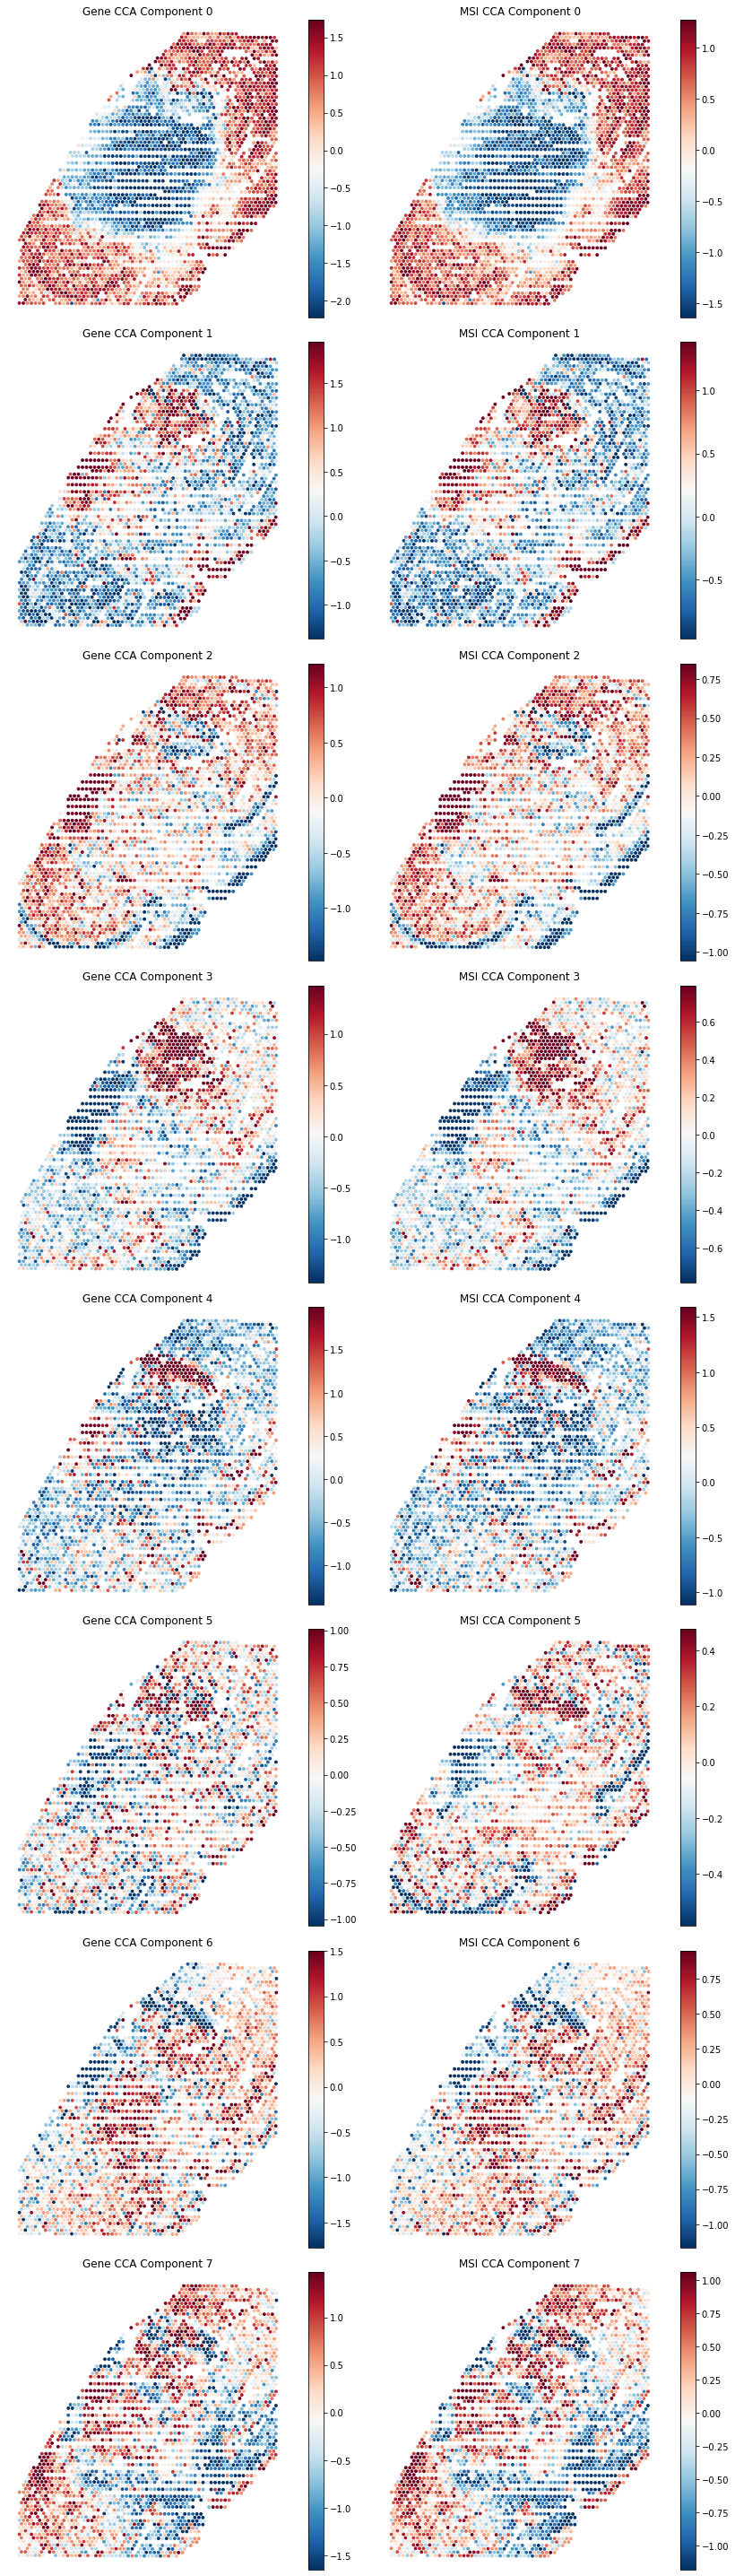

In [22]:
fig, axes = plt.subplots(8, 2, figsize=(12, 40))
for i in range(8):
    for col_idx, (key, label) in enumerate([("cca_gene", "Gene CCA"), ("cca_msi", "MSI CCA")]):
        ax  = axes[i, col_idx]
        col = df[f"{key}_{i}"]
        sc  = ax.scatter(df["x"], df["y"], c=col, cmap="RdBu_r",
                         vmin=np.percentile(col, 5), vmax=np.percentile(col, 95), s=8)
        plt.colorbar(sc, ax=ax)
        ax.set_title(f"{label} Component {i}")
        ax.set_aspect("equal")
        ax.axis("off")

plt.tight_layout()
plt.savefig("/Users/mridulav/spatial_cca_components3.png", dpi=150)
plt.show()

In [23]:
best_comp = 0

sig_genes = gene_corrs_all[best_comp][gene_corrs_all[best_comp]["r_abs"] > 0.25]["gene"].tolist()
sig_msi   = msi_corrs_all[best_comp][msi_corrs_all[best_comp]["r_abs"] > 0.5]["msi"].tolist()

print("Sig genes:", len(sig_genes))
print("Sig msi:", len(sig_msi))

pairs = pd.DataFrame([
    {"gene": g, "msi": m, "component": best_comp,
     "r": pearsonr(X[:, gene_names.index(g)], Y[:, msi_names.index(m)])[0]}
    for g in sig_genes for m in sig_msi
]).assign(r_abs=lambda d: d["r"].abs()).sort_values("r_abs", ascending=False)

print(pairs.head(20)[["gene", "msi", "r"]].to_string(index=False))
pairs.to_csv("/Users/mridulav/gene_metabolite_pairs_mouse_V11T16_085_C1.csv", index=False)

Sig genes: 47
Sig msi: 101
   gene          msi         r
Slc17a7 mz.822.27959  0.482061
Slc17a7  mz.554.0458  0.468779
Slc17a7 mz.555.04915  0.459020
Slc17a7 mz.697.23266  0.457684
Slc17a7 mz.698.23612  0.456205
Slc17a7 mz.428.14952  0.455821
Slc17a7 mz.432.08618  0.455016
Slc17a7 mz.431.08294  0.453396
Slc17a7 mz.382.14402  0.452522
Slc17a7 mz.427.13738  0.450687
Slc17a7 mz.699.22822  0.450670
Slc17a7 mz.373.17158 -0.447017
Slc17a7  mz.697.2391  0.446115
Slc17a7 mz.698.24258  0.445915
Slc17a7 mz.426.13386  0.444822
Slc17a7  mz.426.1394  0.441500
Slc17a7  mz.554.0519  0.440030
Slc17a7  mz.429.1528  0.439060
Slc17a7 mz.428.14054  0.438564
Slc17a7 mz.433.08094  0.438070
